Author: Daniel Abadjiev  
Date: Apr 27, 2026  
Description: Play around with some models to get a data rate.  

In [10]:
import tensorflow as tf
from datetime import datetime
from tfLoaderUtils import *
import numpy as np
import qkeras
import matplotlib.pyplot as plt
import dataRateUtils 
modelType = 1
from typing import Callable, Any, Protocol
import functools
from validationPlots.plotUtils import *
import pandas as pd
import varPredPlotUtils

In [13]:
filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_quantized_4w0i_hyperparameter_results_20260222_004048/model_trial_000.h5"
filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_quantized_8w0i_hyperparameter_results_20260228_020952/model_trial_0.h5"
filepath="./model_trial_0.h5"
if modelType==2:
    filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_qi_4w0i_pareto_roc_selected/model_trial_25.h5"
    filepath="../eric/Model2_5_tahn/model2.5_quantizedinputs_8w0i_pareto_roc_selected/model_trial_065.h5"
    filepath="../eric/model2.5_quantizedinputs_quantized_3w0i_normalized_run_hyperparameter_results_20260430_185058/model_trial_004.h5"
# filepath = "../../smart-pixels-ml/DanielModels/model2_20260325.keras"
#Now trying an Ryan model
if modelType==1:
    filepath="/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/ryan/old_quantization_res/model1_quantized_4w0i_pareto/model_trial_034.h5"
co = {}       
qkeras.utils._add_supported_quantized_objects(co)
quantizedModel = tf.keras.models.load_model(filepath,custom_objects=co,compile=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir_catapult = "./hlsCatapultModel2_"+timestamp
output_dir_vitis = "./hlsVitisModel2_"+timestamp
print("2" in quantizedModel.name[3:7])
quantizedModel.summary()

False
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 z_global (InputLayer)       [(None, 1)]                  0         []                            
                                                                                                  
 x_size (InputLayer)         [(None, 1)]                  0         []                            
                                                                                                  
 concatenate_3 (Concatenate  (None, 2)                    0         ['z_global[0][0]',            
 )                                                                   'x_size[0][0]']              
                                                                                                  
 y_size (InputLayer)         [(None, 1)]                  0         []                

In [4]:
dataRateUtils.modelSpecsToDataRate(2.5, quantizedModel)


Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41
Evaluating Model2.5 [justThisOne]...
41/41 [==============================] - 11s 257ms/step
Data rate at fpr 0.25564112099800146 and threshold [0.625]
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41
Data rate at fpr 0.35247822314137045 and threshold [0.08203125]
Data rate at fpr 1.0 and threshold [0.]
✓ Model2.5 evaluation completed!
  Test Loss: 0.5128
  Test Accuracy: 0.8329
  ROC AUC: 0.8590

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.7444 (FPR = 0.255641), Back Data Accep = 0.1235
    @ 98% signal efficiency: Bkg Rej = 0.6475 (FPR = 0.352478), Back Data Accep = 0.2178
    @ 99% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.2253


In [2]:
varPredPlotUtils.runModelPlots(interactivePlots=False)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Evaluating Model2.5 [justThisOne]...
41/41 [==============================] - 3s 54ms/step


Data rate at fpr 0.14318454621592122 and threshold [0.74609375]
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Data rate at fpr 0.23387182115310773 and threshold [0.51171875]
Data rate at fpr 0.26916227501277434 and threshold [0.3828125]
✓ Model2.5 evaluation completed!
  Test Loss: 0.3310
  Test Accuracy: 0.8726
  ROC AUC: 0.9286

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.8568 (FPR = 0.143185), Back Data Accep = 0.0890
    @ 98% signal efficiency: Bkg Rej = 0.7661 (FPR = 0.233872), Back Data Accep = 0.1634
    @ 99% signal efficiency: Bkg Rej = 0.7308 (FPR = 0.269162), Back Data Accep = 0.1891


/home/dabadjiev/miniconda3/envs/newHLSEnviro/lib/python3.8/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['nPix'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


41/41 [==============================] - 3s 54ms/step
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Plot saved as: ./ratePlots/predStratPlot_PtVsPrediction.png
Plot saved as: ./ratePlots/predStratPlot_XSizeVsPrediction.png
Plot saved as: ./ratePlots/predStratPlot_YSizeVsPrediction.png
Plot saved as: ./ratePlots/predStratPlot_ZGlobalVsPrediction.png
Plot saved as: ./ratePlots/predStratPlot_YLocalVsPrediction.png
Plot saved as: ./ratePlots/predStratPlot_nPixVsPrediction.png
Plot saved as: ./ratePlots/predStratPlot_ZGlobalXSize.png
Plot saved as: ./ratePlots/predStratPlot_ZglobalYsize.png
Plot saved as: ./ratePlots/predStratPlot_YlocalXsize.png
Plot saved as: ./ratePlots/predStratPlot_YlocalYsize.png


In [5]:
# raise ValueError("end notebook here")

In [6]:

# # if loadTestVectors:
# #     [yTest, xTestList] = pickle.load(open(f"./testVectors{modelType}.pkl",'rb'))
# #     xTest = pickle.load(open(f"./tfTestVectors{modelType}.pkl",'rb'))
    
# #     # [yTest, xTestList] = pickle.load(open(f"./testVectors.pkl",'rb'))
# #     # xTest = pickle.load(open(f"./tfTestVectors.pkl",'rb'))
# # else:
# # xTest, yTest, xTestList, xTrain, yTrain = flattenTfData(modelType)
# xTestWithNpix, yTestWithNpix, xTestListWithNpix, xTrainWithNpix, yTrainWithNpix, = flattenTfData(modelType,includenPix=True)
# #     if saveTestVectors:
# #         pickle.dump([yTest, xTestList],open(f"./testVectors{modelType}.pkl","wb"))
# #         pickle.dump(xTest,open(f"./tfTestVectors{modelType}.pkl","wb"))
# # # xTest, yTest, = flattenTfData(2,doTrain=False)

In [3]:
#Now in dataRateUtils.modelSpecsToDataRate
tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized"
tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized"
model = Model2_5(tfRecordFolder = tfRecordFolder)   
configName = "justThisOne"
model.models[configName] = quantizedModel
model.evaluate(config_name=configName,predictionPlots=False)
predictions = model.models[configName].predict(model.validation_generator, verbose=1)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Evaluating Model2.5 [justThisOne]...
41/41 [==============================] - 9s 206ms/step


Data rate at fpr 0.14318454621592122 and threshold [0.74609375]
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Data rate at fpr 0.23387182115310773 and threshold [0.51171875]
Data rate at fpr 0.26916227501277434 and threshold [0.3828125]
✓ Model2.5 evaluation completed!
  Test Loss: 0.3310
  Test Accuracy: 0.8726
  ROC AUC: 0.9286

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.8568 (FPR = 0.143185), Back Data Accep = 0.0890
    @ 98% signal efficiency: Bkg Rej = 0.7661 (FPR = 0.233872), Back Data Accep = 0.1634
    @ 99% signal efficiency: Bkg Rej = 0.7308 (FPR = 0.269162), Back Data Accep = 0.1891


/home/dabadjiev/miniconda3/envs/newHLSEnviro/lib/python3.8/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['nPix'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


41/41 [==============================] - 2s 52ms/step


In [6]:
import tfLoaderUtils
xTest, yTest = tfLoaderUtils.getXYtest(model)
print(yTest.numpy().ravel()==0)


[False False  True ... False  True  True]


In [6]:
# print(xTest.keys())
from matplotlib import colors
keys = ["nModule","x_local","z_global","y_local","nPix"]
keys =  list(set(keys) & set(xTest.keys()))
print(keys)
for idk,key in enumerate(keys):
    backX = (xTest[key][(yTest.numpy().ravel()==0)]).numpy()
    sigX = (xTest[key][(yTest.numpy().ravel()==1)]).numpy()
    predBack = predictions[(yTest.numpy().ravel()==0)]
    predSig = predictions[(yTest.numpy().ravel()==1)]
    plt.figure(figsize=(5,8))
    plt.subplot(4,1,1)
    plt.plot(predBack,backX,".",alpha=0.5,label="background",markersize=2)
    plt.plot(predSig,sigX,".",alpha=0.5,label="Signal",markersize=2)
    plt.legend()
    plt.ylabel(key)
    plt.title(f"{key} vs. neural network prediction")
    plt.subplot(4,1,2)
    plt.hist2d(predictions.ravel(),xTest[key].numpy(),norm=colors.LogNorm())
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel(key)
    plt.title("all test vectors")
    # plt.show()
    plt.subplot(4,1,3)
    plt.hist2d(predBack.ravel(),backX,norm=colors.LogNorm())
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel(key)
    plt.title("just background")
    # plt.show()
    plt.subplot(4,1,4)
    plt.hist2d(predSig.ravel(),sigX,norm=colors.LogNorm())
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel(key)
    plt.title("just signal")
    plt.tight_layout()
    plt.show()

plt.hist2d(predictions.ravel(),yTest.numpy().ravel(),norm=colors.LogNorm())
plt.xlabel("predictions")
plt.ylabel("Bib vs. signal")
plt.colorbar()

NameError: name 'xTest' is not defined

In [ ]:

predVarDF = getPredVarDF(model,predictions)
# keys = ["nModule","x_local","y_local","nPix"]
# # {}
#undo normalization


# qq = genEtaAlphaBetaRq(predVarDF) #missing some stuff
# predVarDF = pd.DataFrame.from_dict({key:xTest[key].numpy() for key in keys})
# predVarDF["prediction"] = predictions.ravel()
# predVarDF["trueY"] = yTest.numpy()
# predVarDF = predVarDF.rename(columns={})

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41


In [1]:
# predVarDF["xSize"] = np.exp(predVarDF["xSize"])
# plt.hist(predVarDF["xSize"] )
# plt.show()
# def plotPtPrediction(truthDF,title="",setPredBins=True):
#     if setPredBins:
#         predBins = np.linspace(-0.1,1,50)
#     else:
#         predBins = 50
#     plotVarPrediction(truthDF,"pt","pT (MeV)",predBins = predBins,title=title,)





# def plot2dHistForModelPred(model,predictions): #refine, then once done use it into script
#     predVarDF = getPredVarDF(model,predictions)
#     # keys = ["nModule","x_local","y_local","nPix"]
#     # # {}
#     #undo normalization
#     predVarDF["xSize"] = 21*(predVarDF["xSize"])
#     predVarDF["ySize"] = 13*(predVarDF["ySize"])
#     plotXYSizeLocPerPred(predVarDF)


    
# def plotYlocalXYsizeJust1(truthDF, title=""):    
#     plot2by2BibSig2dHisto(truthbib,truthsig,'y-local','xSize','y-local','ySize',mask_bib,mask_sig,
#                           binsYlocal,binsXSize,binsYlocal,binsYSize,'Blues','','x-size (# pixels)',
#                           'y-local [μm]','y-size (# pixels)',"bib_signal_ylocal_vs_size_2d",PLOT_DIR,interactivePlots)

# plot3by3PredBibSig(predVarDF,plot_func=plotZglobalXsizeJust1,genTitle="ZGlobalXSize")
# plot3by3PredBibSig(predVarDF,plot_func=plotZglobalYsizeJust1,genTitle="ZglobalYsize")
# plot3by3PredBibSig(predVarDF,plot_func=plotYlocalXsizeJust1,genTitle="YlocalXsize")
# plot3by3PredBibSig(predVarDF,plot_func=plotYlocalYsizeJust1,genTitle="YlocalYsize")
# plot3by3PredBibSig(predVarDF,plot_func=plotPtPrediction,genTitle="PtPrediction")

# plotXYSizeLocPerPred(predVarDF)


TypeError: plotVarPrediction() got multiple values for argument 'varKey'

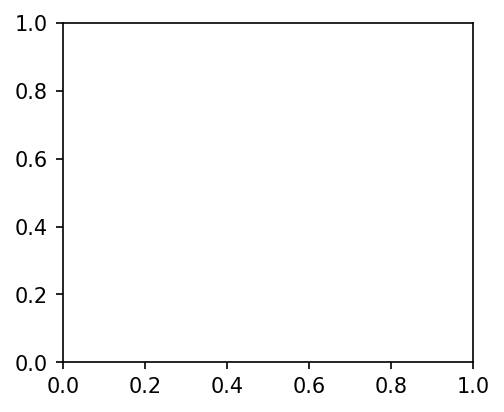

In [11]:
nPixes, yTest = getNpixYtest(model)

In [12]:
# model.evaluate(config_name = configName)

predictions = model.models[configName].predict(model.validation_generator, verbose=1)
print(predictions)
predictions = predictions.ravel()


41/41 [==============================] - 3s 63ms/step
[[0.8359375]
 [0.859375 ]
 [0.       ]
 ...
 [0.875    ]
 [0.15625  ]
 [0.       ]]


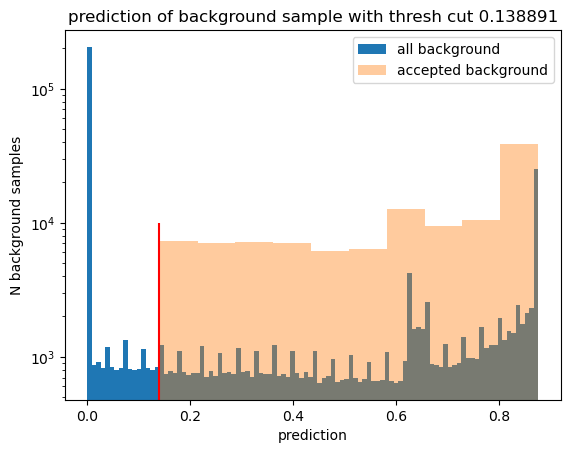


accepted background samples:  112434
total background samples:  330741
backgorund acceptance:  0.3399457581612198
Total background pixel count:  2000084.0
Accepted background pixel count:  482465.0
Data rate of background acceptance:  0.24122237


(482465.0, 2000084.0, 0.24122237)

In [13]:
# nPixes = xTestWithNpix["nPix"]
#functions moved to script
dataRateUtils.pixPredictToDataRate(yTest,nPixes,predictions)


In [ ]:
#functions moved to script
raise ValueError("Definitely end here")


In [15]:
xTest, yTest, xTestList, xTrain, yTrain = flattenTfData(1)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41


KeyboardInterrupt: 

[0.14285715 0.14285715 0.0952381  ... 0.04761905 0.14285715 0.0952381 ]


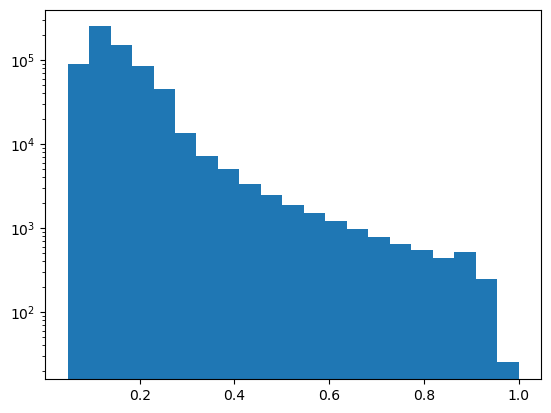

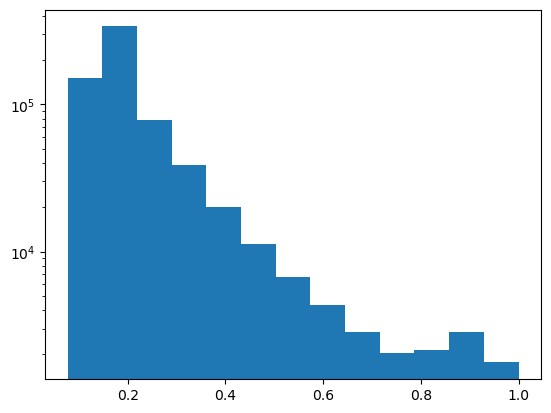

In [ ]:
print(xTest["x_size"].numpy())
plt.hist(xTest["x_size"].numpy(),bins=21)
plt.yscale('log')
plt.show()
plt.hist(xTest["y_size"].numpy(),bins =13)
plt.yscale('log')
plt.show()

In [ ]:
plt.hist(xTest["y_size"])